# Notebook 2 

# Analyse en Composantes Principales (ACP1)

In [162]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


df = pd.read_csv("Mental_Health_Cleaned_Dataset.csv")
df.head()

variables = [
    'Age',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Happiness_Index(1-10)'
]

X = df[variables]



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [163]:
df.describe()

,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
count,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000
mean,33.148847,5.552411,6.287212,6.618449,3.140461,2.448637,8.356394
std,9.926032,1.744059,1.532321,1.545227,1.867226,1.427514,1.532157
min,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,4.000000
25%,24.000000,4.300000,5.000000,6.000000,2.000000,1.000000,7.000000
50%,34.000000,5.600000,6.000000,7.000000,3.000000,2.000000,9.000000
75%,41.000000,6.700000,7.000000,8.000000,5.000000,3.000000,10.000000
max,49.000000,10.800000,10.000000,10.000000,9.000000,7.000000,10.000000


### Interpretation :
This table summarizes the statistics for $N=477$ individuals (indicated by 'count') across eight quantitative variables.  
.Age: The individuals range from 16 to 49 years old, with an average age (mean) of about 33.15 years.  
.Daily Screen Time (hrs): Screen time varies from 1 to 10.8 hours per day. The average screen time is about 5.52 hours.  
.Sleep Quality (1-10): Sleep quality ranges from 1 to 10. The average quality is about 6.29, suggesting slightly above-average quality.  
.Stress Level (1-10): Stress levels range from 2 to 10. The average stress level is about 6.62, which is moderately high.  
.Days Without Social Media: This variable ranges from 0 to 9 days. The average is about 3.14 days without social media.  
.Exercise Frequency (week): Exercise ranges from 0 to 7 times per week. The average frequency is about 2.45 times per week.  
.Happiness Index (1-10): The index ranges from 4 to 10. The average happiness is about 8.36, suggesting the group is generally quite happy.  

On average, the surveyed group (N=477) reports a high average Happiness Index (8.36) despite also reporting a moderately high average Stress Level (6.62) and an average of 5.52 hours of daily screen time.

### Étape 2 — ACP

In [135]:
pca = PCA()
pca.fit(X_scaled)
coords = pca.transform(X_scaled)
pcs = pca.components_

### Éboulis

Variance individuelle (%): [44.506 15.275 14.231 13.372  6.154  4.075  2.387]
Variance cumulée (%):     [ 44.506  59.78   74.012  87.384  93.538  97.613 100.   ]


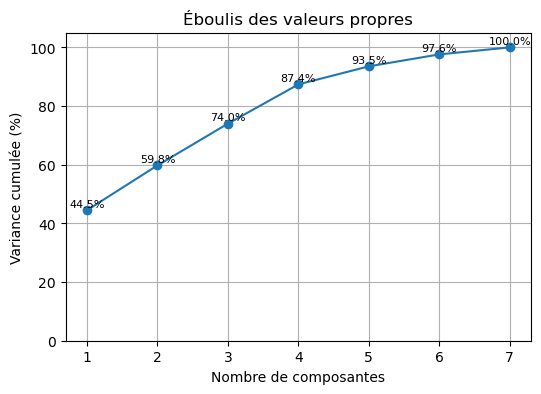

In [136]:

ratio = pca.explained_variance_ratio_ * 100        
cum = np.cumsum(ratio)                           

# Vérification rapide (affiche les valeurs)
print("Variance individuelle (%):", np.round(ratio, 3))
print("Variance cumulée (%):    ", np.round(cum, 3))

# Graphe d'éboulis correct et robuste
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum)+1), cum, marker='o')
plt.xticks(range(1, len(cum)+1))
for i, v in enumerate(cum, start=1):
    plt.text(i, v+1.0, f"{v:.1f}%", ha='center', fontsize=8)  # annoter les points

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée (%)")
plt.title("Éboulis des valeurs propres")
plt.ylim(0, 105)
plt.grid(True)
plt.show()

### Interpretation:
 #### The 1st Principal Component (PC1) explains 44.5% of the total variance.
 #### The 2nd (PC2) explains 15.3%, the 3rd (PC3) explains 14.2%, and so on.
####  We can see that the first 3 components already capture ≈74% of the information ($44.5\% + 15.3\% + 14.2\% = 74.0\%$).

## Cercle des corrélations

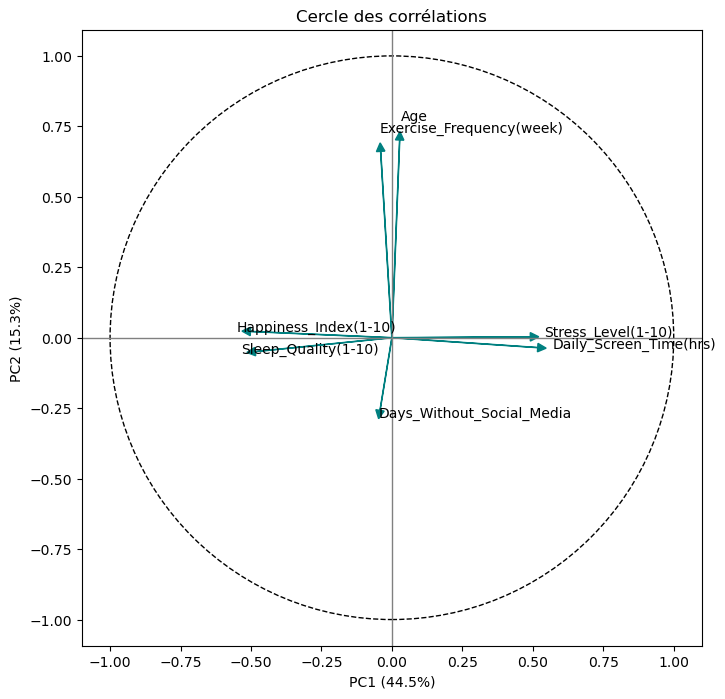

In [137]:
import matplotlib.pyplot as plt

df = pd.read_csv("Mental_Health_Cleaned_Dataset.csv")


cols = ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
        'Stress_Level(1-10)', 'Days_Without_Social_Media',
        'Exercise_Frequency(week)', 'Happiness_Index(1-10)']


pcs = pca.components_  

plt.figure(figsize=(8,8))
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

for i in range(len(cols)):
    plt.arrow(0, 0, pcs[0,i], pcs[1,i], 
              head_width=0.03, head_length=0.03, color='teal')
    plt.text(pcs[0,i]*1.1, pcs[1,i]*1.1, cols[i], fontsize=10)

# Cercle unité
circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='black', linestyle='--')
plt.gca().add_patch(circle)

# Axes avec pourcentage de variance expliquée
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.axis("equal")
plt.show()


### Interpretation:

#### Group 1: The Well-being Factors
Variables: Happiness_Index, Sleep_Quality, and Exercise_Frequency.

Interpretation: These three variables point in a similar direction. They are positively correlated with each other: the more a person exercises, the better they sleep, and the happier they are.

They are positively associated with the first principal component (PC1), which could represent Global Well-being.

#### Group 2: The Distress Factors
Variables: Stress_Level and Daily_Screen_Time.

Interpretation: These two variables are close together and oriented opposite to the previous group. They are positively correlated with each other, but negatively correlated with the well-being variables.

This suggests that as stress and screen time increase, happiness, sleep quality, and physical activity tend to decrease.

#### Group 3:The Role of Digital Detox
Variable: Days_Without_Social_Media.

Interpretation: This variable is close to the well-being (group1), indicating that less social media use is associated with higher well-being.

It is negatively correlated with stress and screen time.

#### Group 4:The Role of Age
Variable: Age.

Interpretation: The arrow representing Age is shorter and oriented differently. This means that Age is weakly correlated with the first two components.

It does not have a strong impact on the principal relationships observed between the other variables.

#### Conclusion : The analysis confirms that lifestyle habits (physical activity, sleep, and screen use) are intimately and strongly linked to mental health and perceived stress levels. This type of analysis is highly useful for guiding recommendations or prevention policies.

## 5. Carte des individus

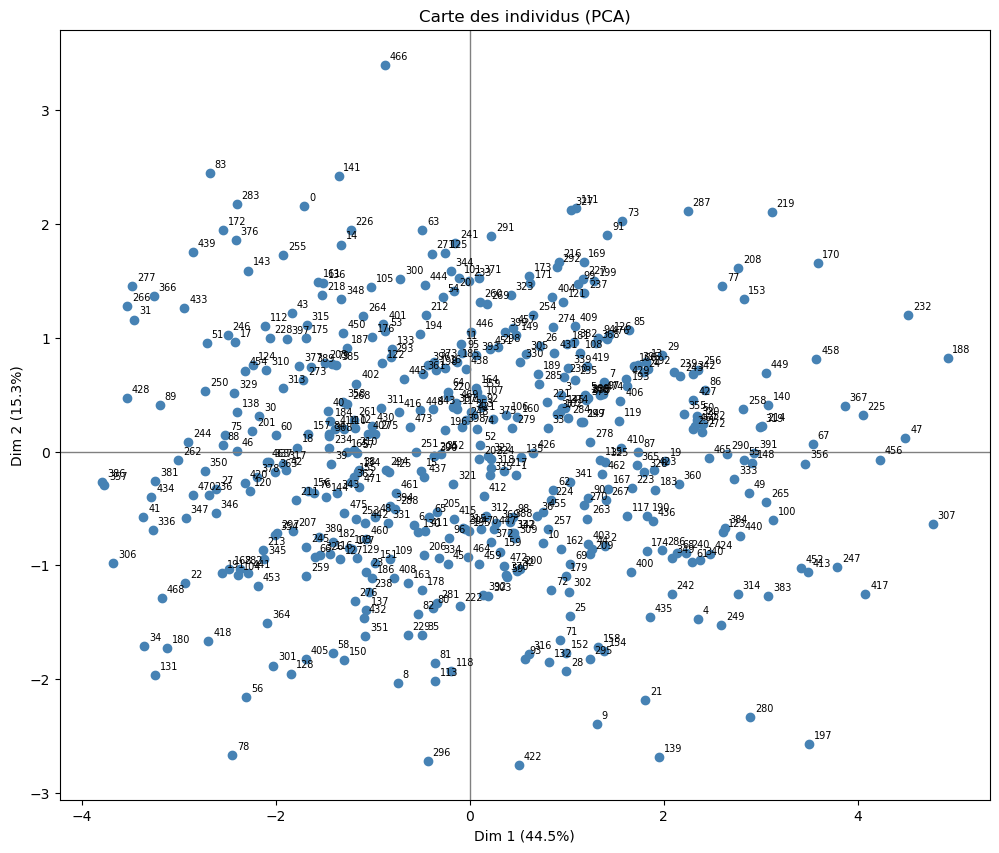

In [138]:
plt.figure(figsize=(12,10))
plt.scatter(coords[:,0], coords[:,1], color='steelblue')

for i, label in enumerate(df.index):
    plt.text(coords[i,0]+0.05, coords[i,1]+0.05, label, fontsize=7)

plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

plt.xlabel(f"Dim 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Carte des individus (PCA)")
plt.show() 

### Interpretation:

#### Interpretation based on Axes (Dim 1 vs. Dim 2)
#### Explained variance:
 • Dim 1 explains 44.5% of the total variability.  
 • Dim 2 explains 15.3% of the total variability.  
Together, these two dimensions provide a moderate but meaningful summary of the individuals’ structure.  
#### Dim 1 (Horizontal Axis) represents the dominant contrast between individual profiles:  
 • Right side: individuals strongly characterized by variables positively correlated with Dim 1 (Profile A).  
 • Left side: individuals characterized by variables negatively correlated with Dim 1 (Profile B).  
Individuals far from the vertical axis show very marked profiles, while those near the center have average characteristics.  
#### Dim 2 (Vertical Axis) plays a secondary but discriminating role:  
 • Top: individuals with high values on variables positively associated with Dim 2.  
 • Bottom: individuals with high values on variables negatively associated with Dim 2.  
This axis refines the separation already created by Dim 1.  
#### Distribution of individuals:  
 • The dense concentration around the origin indicates a large group of individuals with balanced or mixed profiles.  
 • Individuals located in the four quadrants represent distinct combinations of Dim 1 and Dim 2 characteristics.  
 • Extreme points (far from the center) correspond to atypical or highly specific profiles.  
 • Overall interpretation:  
The map shows a continuous gradient rather than clearly separated clusters, with Dim 1 structuring the population globally and Dim 2 introducing   secondary differentiation among individuals.

In [139]:
components_df = pd.DataFrame(
    pca.components_,
    columns=cols,  # ← uniquement les variables utilisées
    index=[f"Dim{i+1}" for i in range(len(pca.components_))]
)

print(components_df.iloc[:2, :])



           Age  Daily_Screen_Time(hrs)  Sleep_Quality(1-10)  \
Dim1  0.027490                0.517370            -0.484776   
Dim2  0.701503               -0.035027            -0.049279   

      Stress_Level(1-10)  Days_Without_Social_Media  Exercise_Frequency(week)  \
Dim1            0.491133                  -0.042195                 -0.039843   
Dim2            0.003164                  -0.257798                  0.661269   

      Happiness_Index(1-10)  
Dim1              -0.501982  
Dim2               0.022185  


### Interpretation:

Dim1: Dominant variables: Daily_Screen_Time, Stress_Level, Sleep_Quality, Happiness_Index.

Meaning: The higher Dim1, the more the individual has high screen time and stress, but low sleep quality and happiness.

We can call Dim1: “Lifestyle / Negative Well-being” axis.

Dim2: Dominant variables: Age, Exercise_Frequency.

Meaning: The higher Dim2, the older and more active the individual.

We can call Dim2: “Age and Physical Activity” axis.

## 6.Contributions des variables

In [140]:
pcs = pca.components_

# Contributions = carré des loadings × 100
contrib = (pcs**2) * 100

contrib_df = pd.DataFrame(
    contrib.T,                 # transposé pour avoir les variables en lignes
    index=cols,                # noms des variables
    columns=[f"Dim{i+1}" for i in range(pcs.shape[0])]
)

#  Afficher les contributions des deux premières dimensions
print("Contributions des variables :")
print(contrib_df.iloc[:, :2])


Contributions des variables :
                                Dim1       Dim2
Age                         0.075570  49.210607
Daily_Screen_Time(hrs)     26.767143   0.122686
Sleep_Quality(1-10)        23.500741   0.242838
Stress_Level(1-10)         24.121143   0.001001
Days_Without_Social_Media   0.178040   6.645974
Exercise_Frequency(week)    0.158746  43.727678
Happiness_Index(1-10)      25.198617   0.049216


### Interpretation :
Interpretation Dim1:

Dominant variables:

Daily_Screen_Time, Sleep_Quality, Stress_Level, Happiness_Index

Meaning of Dim1: “Lifestyle and Well-being” axis

High value → high screen time and stress, low sleep quality and happiness.

Interpretation Dim2:

Dominant variables:

Age, Exercise_Frequency

Meaning of Dim2: “Age and Physical Activity” axis

High value → older and more active individuals

Low value → younger and less active individuals

## 7. Qualité de représentation COS²

In [141]:
# 1) Loadings (coordonnées des variables sur les axes PCA)
pcs = pca.components_

# 2) cos² = carré des loadings
cos2 = pcs**2

# 3) DataFrame propre : variables en lignes, dimensions en colonnes
cos2_df = pd.DataFrame(
    cos2.T,
    index= cols,
    columns=[f"Dim{i+1}" for i in range(pcs.shape[0])]
)

# 4) Afficher les cos² des deux premières dimensions
print("Cos² des variables :")
print(cos2_df.iloc[:, :2])

Cos² des variables :
                               Dim1      Dim2
Age                        0.000756  0.492106
Daily_Screen_Time(hrs)     0.267671  0.001227
Sleep_Quality(1-10)        0.235007  0.002428
Stress_Level(1-10)         0.241211  0.000010
Days_Without_Social_Media  0.001780  0.066460
Exercise_Frequency(week)   0.001587  0.437277
Happiness_Index(1-10)      0.251986  0.000492


## 1. Filtrer les individus avec COS² > 0.70 sur l’axe 1

In [142]:
filtre_dim1 = cos2_ind_df[cos2_ind_df["Dim1"] > 0.70]

print("Individus bien représentés sur Dim1 (COS² > 0.70) :")
print(filtre_dim1)

Individus bien représentés sur Dim1 (COS² > 0.70) :
        Dim1      Dim2      Dim3          Dim4
17  0.743804  0.233233  0.007123  1.584064e-02
19  0.972123  0.001334  0.000282  2.626055e-02
27  0.853940  0.124252  0.000008  2.180019e-02
29  0.734108  0.242949  0.009820  1.312297e-02
41  0.847186  0.066242  0.085309  1.263306e-03
42  0.818266  0.179589  0.000223  1.921216e-03
44  0.973914  0.008887  0.001338  1.586127e-02
46  0.760388  0.010984  0.032727  1.959006e-01
47  0.862186  0.078359  0.031077  2.837838e-02
49  0.912819  0.003925  0.000146  8.310996e-02
51  0.892149  0.059440  0.013344  3.506681e-02
68  0.736680  0.110452  0.127813  2.505550e-02
72  0.805525  0.027390  0.026986  1.400986e-01
75  0.907166  0.000749  0.092044  4.134285e-05
79  0.703769  0.014389  0.196685  8.515676e-02
87  0.965630  0.000014  0.000778  3.357785e-02
88  0.903129  0.007333  0.040298  4.923971e-02
89  0.925489  0.048551  0.025961  6.278052e-08


## 2. Filtrer les individus avec COS² > 0.70 sur l’axe 2

In [143]:
filtre_dim2 = cos2_ind_df[cos2_ind_df["Dim2"] > 0.70]
print("Individus bien représentés sur Dim2 (COS² > 0.70) :")
print(filtre_dim2)

Individus bien représentés sur Dim2 (COS² > 0.70) :
        Dim1      Dim2      Dim3      Dim4
3   0.241477  0.710947  0.007334  0.040242
8   0.102082  0.838460  0.001708  0.057750
11  0.043686  0.799360  0.155846  0.001108
26  0.012040  0.958573  0.028487  0.000899
35  0.104657  0.868071  0.008286  0.018987
58  0.066064  0.906578  0.006540  0.020819
66  0.266268  0.701234  0.000099  0.032399
73  0.067078  0.864805  0.029282  0.038834
77  0.134073  0.801489  0.062608  0.001831
78  0.030762  0.960158  0.000264  0.008815
82  0.012488  0.783081  0.019246  0.185185
91  0.000529  0.976921  0.018519  0.004031
95  0.153456  0.833378  0.009519  0.003648
99  0.002816  0.825674  0.017640  0.153870


## 3. Filtre combiné : Dim 1 OU Dim 2 > 0.70

In [144]:
filtre_1_ou_2 = cos2_ind_df[(cos2_ind_df["Dim1"] > 0.50) & 
                            (cos2_ind_df["Dim2"] > 0.50)]
print("Individus bien représentés sur Dim1 et Dim2 :")
print(filtre_1_ou_2)

Individus bien représentés sur Dim1 et Dim2 :
Empty DataFrame
Columns: [Dim1, Dim2, Dim3, Dim4]
Index: []


## Filtre combiné Dim1 + Dim2 > 0.70

In [145]:
filtre_2dims = cos2_ind_df[
    (cos2_ind_df["Dim1"] > 0.60) &
    (cos2_ind_df["Dim2"] > 0.60)
]

print("Individus très bien représentés sur Dim1 ET Dim2 (COS² > 0.60) :")
print(filtre_2dims)

Individus très bien représentés sur Dim1 ET Dim2 (COS² > 0.60) :
Empty DataFrame
Columns: [Dim1, Dim2, Dim3, Dim4]
Index: []


## ////////////////////////////////////////////////////////////////////////////////////////////////////////

## ////////////////////////////////////////////////////////////////////////////////////////////////////////

# Analyse en Composantes Principales (ACP2)

### Étape 1 — Charger ton dataset

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('Mental_Health_Cleaned_Dataset.100.csv')

# Sélectionner les 4 variables pour l'analyse
selected_vars = ['Age', 'Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Exercise_Frequency(week)']
df_selected = df[selected_vars].copy()


df_selected['Age'] = df['Age'].values
df_selected['Gender'] = df['Gender'].values

X = df_selected[selected_vars].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables utilisées pour PCA:")
print(df_selected.head())


Variables utilisées pour PCA:
   Age  Daily_Screen_Time(hrs)  Stress_Level(1-10)  Exercise_Frequency(week)  \
0   44                     3.1                 6.0                       5.0   
1   36                     5.7                 8.0                       1.0   
2   34                     7.0                 7.0                       1.0   
3   38                     6.6                 7.0                       3.0   
4   26                     7.8                 8.0                       0.0   

   Gender  
0    Male  
1  Female  
2  Female  
3    Male  
4  Female  


In [170]:

df[selected_vars].describe()

,Age,Daily_Screen_Time(hrs),Stress_Level(1-10),Exercise_Frequency(week)
count,100.000000,100.000000,100.000000,100.000000
mean,32.170000,5.414000,6.560000,2.330000
std,9.431363,1.829446,1.532938,1.463737
min,16.000000,1.000000,3.000000,0.000000
25%,24.000000,4.000000,6.000000,1.000000
50%,31.500000,5.700000,7.000000,2.000000
75%,40.000000,6.900000,8.000000,3.000000
max,49.000000,9.700000,10.000000,7.000000


### Interpretation :
The table provides a summary of four quantitative variables for $N=100$ individuals (indicated by 'count').  
Age: The individuals range from 16 to 49 years old, with an average age (mean) of about 32.17 years.   
    .Half of the individuals are between 24 and 40 years old (25th to 75th percentile).  
Daily Screen Time (hrs): The screen time varies from 1 to 9.7 hours per day.  
    .The average screen time is about 5.41 hours.  
Stress Level (1-10): Stress levels range from 3 to 10 on the scale.   
    .The average stress level is about 6.57.  
Exercise Frequency (week): Exercise frequency ranges from 0 to 7 times per week.   
    .The average frequency is about 2.33 times per week.

### Étape 2 — ACP

In [147]:
pca = PCA()
coords = pca.fit_transform(X_scaled)
pcs = pca.components_

### Éboulis


Variance expliquée par composante (%): [43.01 29.85 19.76  7.38]
Variance cumulée (%): [ 43.01  72.86  92.62 100.  ]


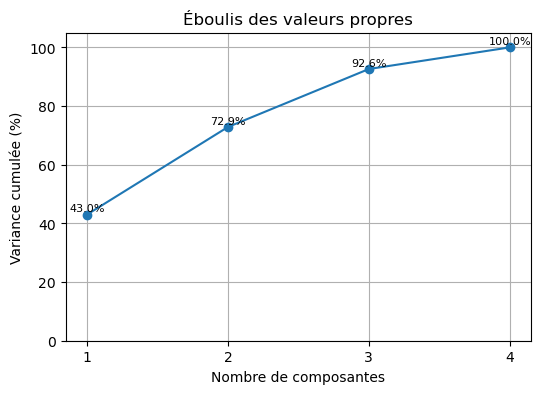

In [148]:
explained_var_ratio = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(explained_var_ratio)

print("\nVariance expliquée par composante (%):", np.round(explained_var_ratio, 2))
print("Variance cumulée (%):", np.round(cum_var, 2))

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xticks(range(1, len(cum_var)+1))
for i, v in enumerate(cum_var, start=1):
    plt.text(i, v+1, f"{v:.1f}%", ha='center', fontsize=8)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée (%)")
plt.title("Éboulis des valeurs propres")
plt.ylim(0, 105)
plt.grid(True)
plt.show()


### Interpretation:
#### The 1st Principal Component (PC1) explains 43.0% of the total variance.
#### The 2nd (PC2) explains 29.85% of the total variance
#### We can see that the first 2 components already capture ≈73% of the information ($43.0\% + 29.85\% = 72.86\%$).

## Cercle des corrélations

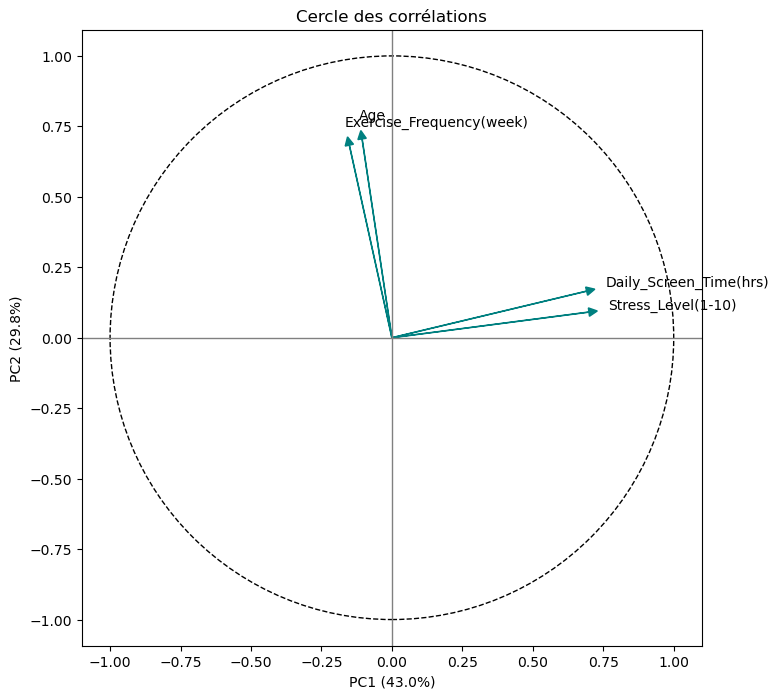

In [149]:
import matplotlib.pyplot as plt

# Tes variables utilisées pour le PCA (selon vos conditions)
cols = ['Age', 'Daily_Screen_Time(hrs)', 'Stress_Level(1-10)', 'Exercise_Frequency(week)']

# Coordonnées des variables sur les 2 premières composantes
pcs = pca.components_  # shape = (n_components, n_features)

plt.figure(figsize=(8,8))
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

for i in range(len(cols)):
    plt.arrow(0, 0, pcs[0,i], pcs[1,i], 
              head_width=0.03, head_length=0.03, color='teal')
    plt.text(pcs[0,i]*1.1, pcs[1,i]*1.1, cols[i], fontsize=10)

# Cercle unité
circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='black', linestyle='--')
plt.gca().add_patch(circle)

# Axes avec pourcentage de variance expliquée
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.axis("equal")
plt.show()

### Interpretation :


#### Group 1: Physical Activity & Age Factors
Variables: Age, Exercise_Frequency(week).

Interpretation: These two variables point in a similar direction and are positively correlated with each other. This suggests that older participants may tend to exercise more frequently, or vice versa. They are positively associated with the second principal component (PC2), which could represent a lifestyle or maturity-related dimension.

#### Group 2: Stress & Screen Time Factors
Variables: Stress_Level(1-10), Daily_Screen_Time(hrs).

Interpretation: These variables are closely aligned with each other along the first principal component (PC1). They are positively correlated with each other but oriented almost orthogonally to Age and Exercise_Frequency, indicating that higher stress and longer screen time are somewhat independent of age and exercise habits in this dataset.

## 5. Carte des individus

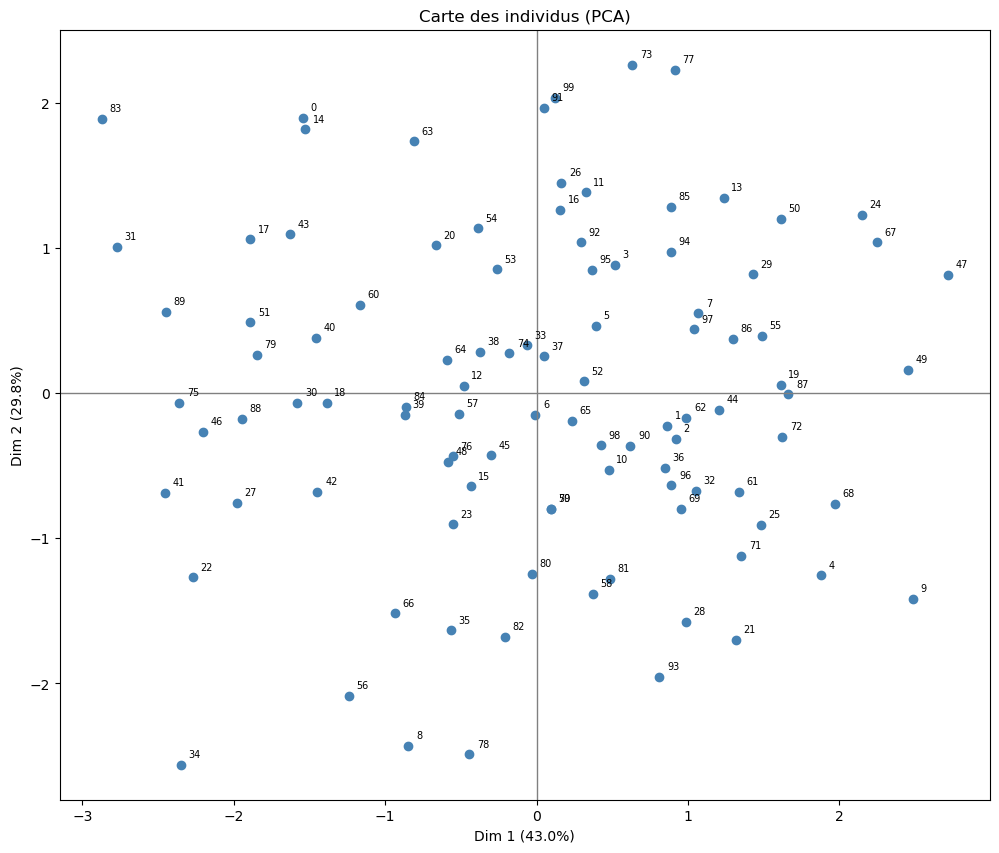

In [150]:
plt.figure(figsize=(12,10))
plt.scatter(coords[:,0], coords[:,1], color='steelblue')

for i, label in enumerate(df.index):
    plt.text(coords[i,0]+0.05, coords[i,1]+0.05, label, fontsize=7)

plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

plt.xlabel(f"Dim 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Carte des individus (PCA)")
plt.show() 

### Interpretation :
#### Interpretation based on Axes (Dim 1 vs. Dim 2)
#### Explained variance:
 • Dim 1 explains 43.0% of the total variability.  
 • Dim 2 explains 29.8% of the total variability.  
Together, they summarize 72.8% of the information, so this map gives a good representation of the individuals.  
#### Dim 1 (Horizontal Axis) mainly separates the individuals into two opposite profiles:
 • Right side: individuals strongly characterized by the variables positively correlated with Dim 1 (Profile A).  
 • Left side: individuals strongly characterized by the variables negatively correlated with Dim 1 (Profile B).  
→ Individuals far from the center on Dim 1 have a more pronounced profile, while those near the origin have an average or mixed profile.  
#### Dim 2 (Vertical Axis) represents a secondary differentiation:
 • Top: individuals with high values on variables positively associated with Dim 2.  
 • Bottom: individuals with high values on variables negatively associated with Dim 2.  
 #### Reading individuals:
An individual far to the right has a strong Profile A.  
An individual far to the left has a strong Profile B.  
An individual far at the top is highly characterized by the Dim 2 traits.  
 Individuals near (0,0) are weakly characterized and close to the average behavior.  
 #### General structure:
The dispersion of points across the four quadrants indicates heterogeneity among individuals, with distinct profiles clearly separated along Dim 1 and refined by Dim 2.

In [160]:
components_df = pd.DataFrame(
    pcs,
    columns=cols,
    index=[f"Dim{i+1}" for i in range(pcs.shape[0])]
)
print("\nMatrice des composantes (PCA):")
print(components_df.iloc[:2, :])  # Affiche seulement Dim1 et Dim2


Matrice des composantes (PCA):
           Age  Daily_Screen_Time(hrs)  Stress_Level(1-10)  \
Dim1 -0.105770                0.690906            0.699042   
Dim2  0.705341                0.165267            0.090984   

      Exercise_Frequency(week)  
Dim1                 -0.151004  
Dim2                  0.683303  


Dim1 :
Dominant variables: Daily_Screen_Time, Stress_Level, Exercise_Frequency, Age
The higher the Dim1 score, the more screen time and stress the person has, while variables like Exercise_Frequency or others may be lower.
Suggested label: “Lifestyle / Negative Well-being” axis

Dim2 :
Dominant variables: Age, Exercise_Frequency
The higher the Dim2 score, the older and more physically active the person is.
Suggested label: “Age and Physical Activity” axis

In [159]:
pca.components_.shape


(4, 4)

## 6.Contributions des variables

In [153]:
pcs = pca.components_  # Loadings of variables on each principal component

# Contributions = squared loadings * 100
contrib = (pcs ** 2) * 100

# Create DataFrame for contributions
contrib_df = pd.DataFrame(
    contrib.T,  # transpose to have variables as rows
    index=cols,  # variable names
    columns=[f"Dim{i+1}" for i in range(pcs.shape[0])]
)

# Display contributions for the first two dimensions
print("Contributions of variables (%):")
print(contrib_df.iloc[:, :2])

Contributions of variables (%):
                               Dim1       Dim2
Age                        1.118735  49.750643
Daily_Screen_Time(hrs)    47.735077   2.731314
Stress_Level(1-10)        48.865967   0.827812
Exercise_Frequency(week)   2.280221  46.690231


### Interpretation:

Interpretation Dim1:

Dominant variables:
Daily_Screen_Time, Stress_Level

Meaning of Dim1: “Screen Time and Stress” axis

High value → high screen time and high stress

Low value → low screen time and low stress

Interpretation Dim2:

Dominant variables:
Age, Exercise_Frequency

Meaning of Dim2: “Age and Physical Activity” axis

High value → older and more active individuals

Low value → younger and less active individuals

## 7. Qualité de représentation COS²

In [154]:
pcs = pca.components_  # Loadings of variables on each PCA dimension

cos2_ind = (coords ** 2) / np.sum(coords ** 2, axis=1, keepdims=True)

# Create DataFrame
cos2_ind_df = pd.DataFrame(
    cos2_ind,
    index=df_selected.index,
    columns=[f"Dim{i+1}" for i in range(pcs.shape[0])]
)

print("COS² des individus (premières lignes)")
print(cos2_ind_df.head())

COS² des individus (premières lignes)
       Dim1      Dim2      Dim3      Dim4
0  0.356279  0.537805  0.024777  0.081139
1  0.388827  0.026241  0.417309  0.167624
2  0.494693  0.058323  0.347827  0.099157
3  0.241477  0.710947  0.007334  0.040242
4  0.628803  0.280922  0.072216  0.018058


### 1. Filtrer les individus avec COS² > 0.70 sur l’axe 1

In [155]:
filtre_dim1 = cos2_ind_df[cos2_ind_df["Dim1"] > 0.70]
print("Individus bien représentés sur Dim1 (COS² > 0.70) :")
print(filtre_dim1)

Individus bien représentés sur Dim1 (COS² > 0.70) :
        Dim1      Dim2      Dim3          Dim4
17  0.743804  0.233233  0.007123  1.584064e-02
19  0.972123  0.001334  0.000282  2.626055e-02
27  0.853940  0.124252  0.000008  2.180019e-02
29  0.734108  0.242949  0.009820  1.312297e-02
41  0.847186  0.066242  0.085309  1.263306e-03
42  0.818266  0.179589  0.000223  1.921216e-03
44  0.973914  0.008887  0.001338  1.586127e-02
46  0.760388  0.010984  0.032727  1.959006e-01
47  0.862186  0.078359  0.031077  2.837838e-02
49  0.912819  0.003925  0.000146  8.310996e-02
51  0.892149  0.059440  0.013344  3.506681e-02
68  0.736680  0.110452  0.127813  2.505550e-02
72  0.805525  0.027390  0.026986  1.400986e-01
75  0.907166  0.000749  0.092044  4.134285e-05
79  0.703769  0.014389  0.196685  8.515676e-02
87  0.965630  0.000014  0.000778  3.357785e-02
88  0.903129  0.007333  0.040298  4.923971e-02
89  0.925489  0.048551  0.025961  6.278052e-08


### 2. Filtrer les individus avec COS² > 0.70 sur l’axe 2

In [156]:
filtre_dim2 = cos2_ind_df[cos2_ind_df["Dim2"] > 0.70]
print("Individus bien représentés sur Dim2 (COS² > 0.70) :")
print(filtre_dim2)


Individus bien représentés sur Dim2 (COS² > 0.70) :
        Dim1      Dim2      Dim3      Dim4
3   0.241477  0.710947  0.007334  0.040242
8   0.102082  0.838460  0.001708  0.057750
11  0.043686  0.799360  0.155846  0.001108
26  0.012040  0.958573  0.028487  0.000899
35  0.104657  0.868071  0.008286  0.018987
58  0.066064  0.906578  0.006540  0.020819
66  0.266268  0.701234  0.000099  0.032399
73  0.067078  0.864805  0.029282  0.038834
77  0.134073  0.801489  0.062608  0.001831
78  0.030762  0.960158  0.000264  0.008815
82  0.012488  0.783081  0.019246  0.185185
91  0.000529  0.976921  0.018519  0.004031
95  0.153456  0.833378  0.009519  0.003648
99  0.002816  0.825674  0.017640  0.153870


### 3. Filtre combiné : Dim 1 OU Dim 2 > 0.70

In [157]:
filtre_1_ou_2 = cos2_ind_df[(cos2_ind_df["Dim1"] > 0.50) & 
                            (cos2_ind_df["Dim2"] > 0.50)]

print("Individus bien représentés sur Dim1 et Dim2 (COS² > 0.50) :")
print(filtre_1_ou_2)

Individus bien représentés sur Dim1 et Dim2 (COS² > 0.50) :
Empty DataFrame
Columns: [Dim1, Dim2, Dim3, Dim4]
Index: []


### Filtre combiné Dim1 + Dim2 > 0.70

In [158]:
filtre_2dims = cos2_ind_df[
    (cos2_ind_df["Dim1"] > 0.60) &
    (cos2_ind_df["Dim2"] > 0.60)
]

print("Individus bien représentés sur Dim1 AND Dim2 (COS² > 0.60) :")
print(filtre_2dims)

Individus bien représentés sur Dim1 AND Dim2 (COS² > 0.60) :
Empty DataFrame
Columns: [Dim1, Dim2, Dim3, Dim4]
Index: []
